In [1]:
import os
import base64
from IPython.display import HTML

video_file_path = 'Spacejam/dataset/examples/0000000_flipped.mp4'


try:
    with open(video_file_path, "rb") as video_file:
        video_bytes = video_file.read()
    video_b64 = base64.b64encode(video_bytes).decode()
    video_tag = f'<video width="640" height="480" controls><source src="data:video/mp4;base64,{video_b64}" type="video/mp4"></video>'
    display(HTML(video_tag))

except FileNotFoundError:
    print(f"Error: Video file not found at {video_file_path}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

In [2]:
#get labels

with open('SpaceJam/dataset/labels_dict.json', 'r') as g:
    labels_wrong = g.read()

data = eval(labels_wrong)

labels = {str(key): i for key, i in data.items()} #converting keys to string rather than integer

labels

{'0': 'block',
 '1': 'pass',
 '2': 'run',
 '3': 'dribble',
 '4': 'shoot',
 '5': 'ball in hand',
 '6': 'defense',
 '7': 'pick',
 '8': 'no_action',
 '9': 'walk',
 '10': 'discard'}

In [3]:
import json

with open('SpaceJam/dataset/annotation_dict.json', 'r') as f:
    annotations = json.load(f)

annotations

{'0014297': 9,
 '0024339': 8,
 '0007545': 9,
 '0021609': 9,
 '0016126': 9,
 '0008080': 9,
 '0006103_flipped': 0,
 '0015195': 9,
 '0015015': 3,
 '0016240': 8,
 '0036279': 8,
 '0013083': 6,
 '0012589': 2,
 '0024942': 9,
 '0003812': 3,
 '0000417': 2,
 '0002127': 2,
 '0027751': 2,
 '0009777': 9,
 '0027376': 8,
 '0009722': 2,
 '0006374_flipped': 7,
 '0027741': 2,
 '0034771': 8,
 '0014021': 9,
 '0018453': 6,
 '0009254': 6,
 '0023268': 2,
 '0002939': 2,
 '0016195': 6,
 '0019076_flipped': 3,
 '0026722': 9,
 '0006616': 9,
 '0034041': 6,
 '0003290_flipped': 7,
 '0025974': 2,
 '0020817': 6,
 '0018514': 8,
 '0011164': 9,
 '0016411': 6,
 '0018290': 5,
 '0000663': 9,
 '0004986': 9,
 '0014011': 5,
 '0015217': 0,
 '0026903': 9,
 '0008101_flipped': 7,
 '0004772': 7,
 '0014341': 9,
 '0000307': 2,
 '0022786': 9,
 '0018407': 6,
 '0035846': 9,
 '0009845_flipped': 3,
 '0019064': 9,
 '0004906': 8,
 '0024670': 9,
 '0025687': 9,
 '0020925': 9,
 '0018588': 9,
 '0011739': 8,
 '0001927': 9,
 '0000026': 7,
 '00149

In [4]:
import pandas as pd

action_video_path = 'Spacejam/dataset/examples/'

#dataframe of names and labels
har_frame = []
for video_name, label in annotations.items():
    video_path = os.path.join(action_video_path, f"{video_name}.mp4") #video clips
    if os.path.exists(video_path): #check file exists
        har_frame.append({"video_path": video_path, "label": label})

har_frame = pd.DataFrame(har_frame)

print("Sample DataFrame:")
print(har_frame.head())

Sample DataFrame:
                              video_path  label
0  Spacejam/dataset/examples/0014297.mp4      9
1  Spacejam/dataset/examples/0024339.mp4      8
2  Spacejam/dataset/examples/0007545.mp4      9
3  Spacejam/dataset/examples/0021609.mp4      9
4  Spacejam/dataset/examples/0016126.mp4      9


In [5]:
print(har_frame.shape)
print(har_frame['label'].value_counts())

(37085, 2)
label
9    11749
8     6490
2     5924
6     3866
3     3490
5     2362
1     1070
0      996
7      712
4      426
Name: count, dtype: int64


In [18]:
%pip install -U matplotlib

  Using cached matplotlib-3.10.1-cp311-cp311-win_amd64.whl.metadata (11 kB)
  Using cached contourpy-1.3.1-cp311-cp311-win_amd64.whl.metadata (5.4 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
Using cached matplotlib-3.10.1-cp311-cp311-win_amd64.whl (8.1 MB)
Using cached contourpy-1.3.1-cp311-cp311-win_amd64.whl (219 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not install packages due to an OSError: [WinError 32] The process cannot access the file because it is being used by another process: 'C:\\Users\\dinod\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\\LocalCache\\local-packages\\Python311\\site-packages\\matplotlib\\backends\\backend_gtk3.py'
Check the permissions.


[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: C:\Users\dinod\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


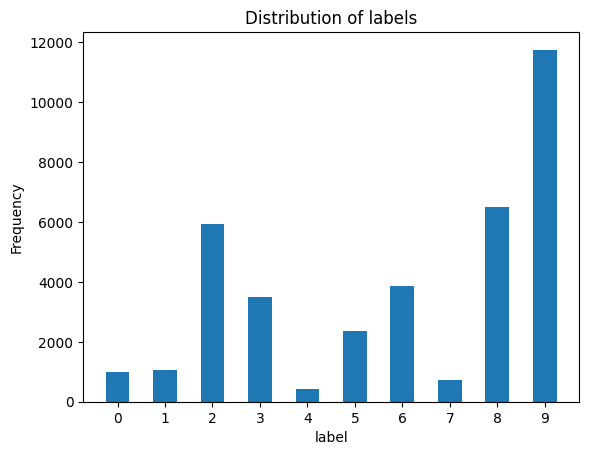

In [6]:
import matplotlib.pyplot as plt
import numpy as np


labels, counts = np.unique(har_frame['label'], return_counts=True)

plt.bar(labels, counts, width=0.5, align='center')

plt.xticks(labels)

plt.xlabel('label')
plt.ylabel('Frequency')
plt.title('Distribution of labels')

plt.show()

Attempt as kinetics rd+1

In [23]:
%pip install torchmetrics

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: C:\Users\dinod\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [47]:
!pip3 install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

Looking in indexes: https://download.pytorch.org/whl/cu118
  Using cached https://download.pytorch.org/whl/cu118/torch-2.6.0%2Bcu118-cp311-cp311-win_amd64.whl.metadata (28 kB)
  Using cached https://download.pytorch.org/whl/cu118/torchaudio-2.6.0%2Bcu118-cp311-cp311-win_amd64.whl.metadata (6.8 kB)
Using cached https://download.pytorch.org/whl/cu118/torch-2.6.0%2Bcu118-cp311-cp311-win_amd64.whl (2728.9 MB)
Using cached https://download.pytorch.org/whl/cu118/torchaudio-2.6.0%2Bcu118-cp311-cp311-win_amd64.whl (4.1 MB)



[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: C:\Users\dinod\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [7]:
import torch
import torchmetrics
from torchmetrics import Accuracy, Precision
from torchvision.models.video import r2plus1d_18, R2Plus1D_18_Weights
from torch.utils.data import Dataset, DataLoader

In [ ]:
class VideoDataset(Dataset):
    def __init__(self, video_paths, labels, num_frames=16, transform=None, oversample=False):
        self.video_paths = video_paths
        self.labels = labels
        self.num_frames = num_frames
        self.transform = transform
        self.oversample = oversample
        
        label_counts = Counter(labels)
        mean_count = np.mean(list(label_counts.values()))
        self.underrepresented = set([label for label, count in label_counts.items() if count < mean_count])

        #over smaple enabled
        if self.oversample:
            augmented_video_paths = []
            augmented_labels = []

            for i in range(len(video_paths)):
                video_path = video_paths[i]
                label = labels[i]
                
                #only under repped
                if label in self.underrepresented:
                    augmented_video_paths.append(video_path)
                    augmented_labels.append(label)
                    
                    for _ in range(2):  #add 2 versions
                        augmented_video_paths.append(video_path)
                        augmented_labels.append(label)

                else:
                    augmented_video_paths.append(video_path)
                    augmented_labels.append(label)

            self.video_paths = augmented_video_paths
            self.labels = augmented_labels

    def __getitem__(self, idx):
        video_path = self.video_paths[idx]
        label = self.labels[idx]

        frames = extract_frames(video_path, self.num_frames)
        frames = torch.from_numpy(frames)

        #apply augmentation to underrepped classes
        if label in self.underrepresented and self.oversample:
            frames = self.augment_frames(frames)

        if self.transform:
            frames = self.transform(frames)

        return frames, label
    
    def augment_frames(self, frames):
        augmented_frames = []
        for frame in frames: #apply each frame
            frame = frame.numpy().transpose(1, 2, 0)  #convert to HWC
            frame = cv2.resize(frame, (128, 128)) #make larger

            if random.random() < 0.5:  #apply crop
                x = random.randint(0, 128 - 112) #crop location
                y = random.randint(0, 128 - 112)
                frame = frame[y:y + 112, x:x + 112]  # Random Crop 112x112
            else: #if not crop resize
                frame = cv2.resize(frame, (112, 112))

            #flip horizontally
            if random.random() < 0.5: #50%
                frame = cv2.flip(frame, 1)

            frame = frame.transpose(2, 0, 1) #back to CHW
            augmented_frames.append(torch.from_numpy(frame))

        return torch.stack(augmented_frames) #Stack back into a tensor


In [ ]:
def extract_frames(video_path, num_frames=16):
    #open video file
    cap = cv2.VideoCapture(video_path)
    frames = []

    #no of frames
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    #interval to expect frames
    frame_interval = max(total_frames // num_frames, 1)

    #loop through and extract frames
    for i in range(num_frames):

        #read current frame
        cap.set(cv2.CAP_PROP_POS_FRAMES, i * frame_interval)
        ret, frame = cap.read()

        #break if video ends
        if not ret:
            break

        frame = cv2.resize(frame, (112, 112))

        #add frame to frame list
        frames.append(frame)

    #close
    cap.release()

    #fill missing frames with blank frames
    while len(frames) < num_frames:
        frames.append(np.zeros((112, 112, 3), np.uint8))

    #convert to numpy
    return np.array(frames).transpose((0, 3, 1, 2)) #for tchw

In [10]:
weights = R2Plus1D_18_Weights.DEFAULT
preprocess = weights.transforms()
pretrained_model = r2plus1d_18(weights=weights)

In [38]:
%pip install scikit-learn

     ---------------------------------------- 0.0/60.8 kB ? eta -:--:--
     ------ --------------------------------- 10.2/60.8 kB ? eta -:--:--
     -------------------------------------- 60.8/60.8 kB 802.0 kB/s eta 0:00:00
   ---------------------------------------- 0.0/11.1 MB ? eta -:--:--
    --------------------------------------- 0.3/11.1 MB 5.2 MB/s eta 0:00:03
   -- ------------------------------------- 0.7/11.1 MB 7.3 MB/s eta 0:00:02
   ---- ----------------------------------- 1.1/11.1 MB 8.0 MB/s eta 0:00:02
   ----- ---------------------------------- 1.6/11.1 MB 8.4 MB/s eta 0:00:02
   ------- -------------------------------- 2.0/11.1 MB 9.1 MB/s eta 0:00:02
   -------- ------------------------------- 2.4/11.1 MB 9.1 MB/s eta 0:00:01
   ---------- ----------------------------- 2.9/11.1 MB 9.2 MB/s eta 0:00:01
   ----------- ---------------------------- 3.3/11.1 MB 9.2 MB/s eta 0:00:01
   ------------- -------------------------- 3.7/11.1 MB 9.2 MB/s eta 0:00:01
   ---------


[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: C:\Users\dinod\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [ ]:
#import sklearn
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
#from sklearn.metrics import classification_report, confusion_matrix
from torch.utils.data.sampler import WeightedRandomSampler

batch_size = 8

video_paths = har_frame["video_path"].tolist()
labels = har_frame["label"].tolist()

#
labelsUnique, counts = np.unique(labels, return_counts=True)
class_weights = 1.0 / torch.tensor(counts, dtype=torch.float)


#dataset splits
video_paths_train, video_paths_val, labels_train, labels_val = train_test_split(
    video_paths, labels, test_size=0.2, random_state=42
)

sample_weights = [class_weights[label] for label in labels_train]  
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(labels_train), replacement=True)


train_dataset = VideoDataset(video_paths_train, labels_train, transform=preprocess, oversample=True)
train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=sampler)


val_dataset = VideoDataset(video_paths_val, labels_val, transform=preprocess)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

In [33]:
import torch
print(torch.cuda.is_available())

True


In [34]:
label_counts = har_frame['label'].value_counts()
print(label_counts)

label
9    11749
8     6490
2     5924
6     3866
3     3490
5     2362
1     1070
0      996
7      712
4      426
Name: count, dtype: int64


In [ ]:
import torch.nn.functional as F
accuracy = Accuracy(task="multiclass", num_classes=10).to('cuda')
precision = Precision(task="multiclass", num_classes=10).to('cuda')

#remove last few layers
pretrained_model.fc = torch.nn.Identity()

for param in pretrained_model.parameters(): #unfreeze
    param.requires_grad = True

num_classes = 10

classification_head = torch.nn.Sequential(
        torch.nn.Linear(512, 256),
        torch.nn.ReLU(),
        torch.nn.Dropout(0.5),
        torch.nn.Linear(256, num_classes),
    )

model = torch.nn.Sequential(
    pretrained_model,
    classification_head
)


optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

class_weights = torch.tensor( #log weights for balancing
    [1.0 / (torch.log(torch.tensor(label_counts.get(i, 1.0)) + 1)) for i in range(num_classes)], 
    dtype=torch.float32
).to(device)

class FocalLoss(torch.nn.Module):
    def __init__(self, alpha=None, gamma=2):
        super(FocalLoss, self).__init__()
        self.alpha = alpha  
        self.gamma = gamma  #importance

    def forward(self, logits, targets):
        ce_loss = F.cross_entropy(logits, targets, reduction='none')
        pt = torch.exp(-ce_loss)  #probability of correct class
        focal_loss = (1 - pt) ** self.gamma * ce_loss
        if self.alpha is not None:
            alpha_factor = self.alpha[targets]  #apply class weights
            focal_loss *= alpha_factor
        return focal_loss.mean()

loss_fn = FocalLoss(alpha=class_weights.to(torch.float32), gamma=2).to(device)

# Training loop
num_epochs = 25
#batch_size = 128
model = model.to('cuda')

In [17]:
%pip install opencv-python-headless

   ---------------------------------------- 0.0/39.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/39.4 MB 320.0 kB/s eta 0:02:04
   ---------------------------------------- 0.1/39.4 MB 1.2 MB/s eta 0:00:34
    --------------------------------------- 0.5/39.4 MB 4.1 MB/s eta 0:00:10
    --------------------------------------- 1.0/39.4 MB 5.5 MB/s eta 0:00:08
   - -------------------------------------- 1.4/39.4 MB 6.7 MB/s eta 0:00:06
   - -------------------------------------- 1.8/39.4 MB 6.8 MB/s eta 0:00:06
   -- ------------------------------------- 2.3/39.4 MB 7.2 MB/s eta 0:00:06
   -- ------------------------------------- 2.7/39.4 MB 7.5 MB/s eta 0:00:05
   --- ------------------------------------ 3.1/39.4 MB 7.7 MB/s eta 0:00:05
   --- ------------------------------------ 3.6/39.4 MB 8.1 MB/s eta 0:00:05
   ---- ----------------------------------- 4.0/39.4 MB 8.2 MB/s eta 0:00:05
   ---- ----------------------------------- 4.4/39.4 MB 8.3 MB/s eta 0:00:05
   -


[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: C:\Users\dinod\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [37]:
import cv2

In [38]:
torch.cuda.empty_cache()

In [ ]:
scaler = torch.cuda.amp.GradScaler()

for epoch in range(num_epochs):
    accuracy.reset()
    precision.reset()
    
    for i, (batch_X, batch_y) in enumerate(train_loader):
        batch_X = batch_X.to('cuda')
        batch_y = batch_y.to('cuda')

        optimizer.zero_grad()

        #mixed precision
        with torch.cuda.amp.autocast():
            outputs = model(batch_X)
            loss = loss_fn(outputs, batch_y)

        #scale loss before backward
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        accuracy.update(outputs, batch_y)
        precision.update(outputs, batch_y)

        if i % 10 == 0:  #print every 10 batches
            print(f"Batch {i + 1}/{len(train_loader)}, "
                  f"Loss: {loss.item():.4f}, "
                  f"Accuracy: {accuracy.compute().item():.4f}, "
                  f"Precision: {precision.compute().item():.4f}")

    #final metrics for epoch
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}, "
          f"Accuracy: {accuracy.compute().item():.4f}, "
          f"Precision: {precision.compute().item():.4f})")

    torch.cuda.empty_cache()

AttributeError: 'VideoDataset' object has no attribute 'augment_frames'

In [20]:
#calculate overall scores on the validation set
model.eval() 
accuracy.reset()
precision.reset()


with torch.no_grad():  #disable gradient
    for batch_X, batch_y in val_loader:
        batch_X = batch_X.to('cuda')
        batch_y = batch_y.to('cuda')

        
        outputs = model(batch_X)
        preds = torch.argmax(outputs, dim=1)

        
        accuracy.update(preds, batch_y)
        precision.update(preds, batch_y)

#overall scores
overall_precision = accuracy.compute()
overall_accuracy = accuracy.compute()
print(f"Overall Accuracy: {overall_accuracy.item():.4f}, Overall Precision: {overall_precision}")

Overall Accuracy: 0.3995, Overall Precision: 0.3994876742362976


Overall Accuracy: 0.6532
Overall Precision: 0.6532
F1 Score (Weighted): 0.6500
Recall (Weighted): 0.6532


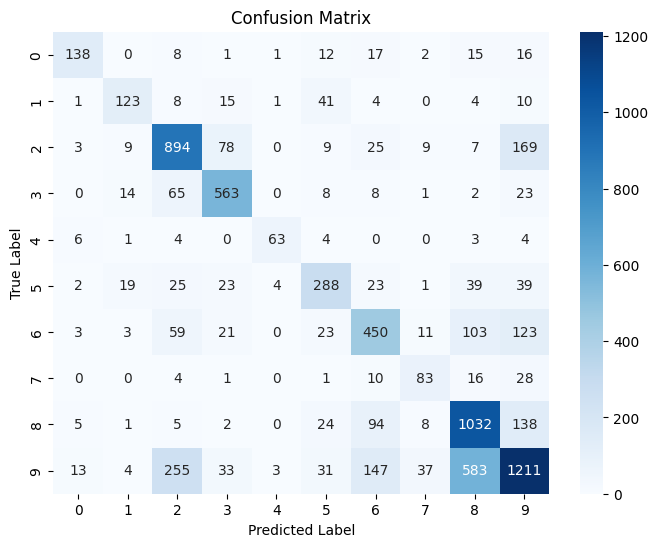


Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.66      0.72       210
           1       0.71      0.59      0.65       207
           2       0.67      0.74      0.71      1203
           3       0.76      0.82      0.79       684
           4       0.88      0.74      0.80        85
           5       0.65      0.62      0.64       463
           6       0.58      0.57      0.57       796
           7       0.55      0.58      0.56       143
           8       0.57      0.79      0.66      1309
           9       0.69      0.52      0.59      2317

    accuracy                           0.65      7417
   macro avg       0.69      0.66      0.67      7417
weighted avg       0.66      0.65      0.65      7417



In [ ]:
import torch
import numpy as np
import pandas as pd
from torchmetrics import Accuracy, Precision
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# evaluation metrics
accuracy = Accuracy(task="multiclass", num_classes=10).to('cuda')
precision = Precision(task="multiclass", num_classes=10).to('cuda')

#evaluation loop
model.eval()
accuracy.reset()
precision.reset()

all_preds = []
all_labels = []

with torch.no_grad():
    for batch_X, batch_y in val_loader:
        batch_X = batch_X.to('cuda')
        batch_y = batch_y.to('cuda')

        outputs = model(batch_X)
        preds = torch.argmax(outputs, dim=1)

        accuracy.update(preds, batch_y)
        precision.update(preds, batch_y)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch_y.cpu().numpy())

#Overall scores
overall_accuracy = accuracy.compute()
overall_precision = precision.compute()

print(f"Overall Accuracy: {overall_accuracy.item():.4f}")
print(f"Overall Precision: {overall_precision.item():.4f}")

from sklearn.metrics import f1_score, recall_score

f1 = f1_score(all_labels, all_preds, average='weighted')
recall = recall_score(all_labels, all_preds, average='weighted')

print(f"F1 Score (Weighted): {f1:.4f}")
print(f"Recall (Weighted): {recall:.4f}")

#Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.arange(10), yticklabels=np.arange(10))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

print("\nClassification Report:")
print(classification_report(all_labels, all_preds))

In [31]:
from sklearn.metrics import precision_score, accuracy_score

precision = precision_score(all_labels, all_preds, average="weighted")
accuracy = accuracy_score(all_labels, all_preds)

print(f"Sklearn Precision: {precision:.4f}, Sklearn Accuracy: {accuracy:.4f}")

Sklearn Precision: 0.6615, Sklearn Accuracy: 0.6532


In [32]:
torch.save(model.state_dict(), "modelv2")

